Pulling data on USD/PLN from Yahoo Finance's yfinance API

In [1]:
# installing libraries commented once installed (to cut runtime for script but please make sure you install libraries)
# !pip install yfinance
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# loading libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

In [3]:
# downloading USD/PLN data from 2019 to February 2026 (pre-COVID, Russia-Ukraine and Liberation Day)
raw = yf.download("USDPLN=X", start="2018-12-31", end="2026-02-28", auto_adjust=True)

# pull closing prices and make sure output is a series not df
spot = raw['Close'].squeeze().dropna()

# checking data shape is what's expected
print(spot.index[0].date(), spot.index[-1].date()) # checking data start and end
print(f"number of trading days is:", len(spot))
print(spot.iloc[-1])

[*********************100%***********************]  1 of 1 completed

2018-12-31 2026-02-27
number of trading days is: 1864
3.5772199630737305


In [6]:
# calculating log returns in line with Ito lemma derivation that shows d(lnS) is normally distributed
spot_data = pd.DataFrame()
spot_data['date'] = spot.index[1:]
spot_data['spot_tday'] = spot.values[1:]
spot_data['spot_yday'] = spot.values[:-1]
spot_data['log_return'] = np.log(spot_data['spot_tday']/spot_data['spot_yday'])
print(spot_data)

           date  spot_tday  spot_yday  log_return
0    2019-01-01    3.74030    3.75685   -0.004415
1    2019-01-02    3.74010    3.74030   -0.000053
2    2019-01-03    3.79770    3.74010    0.015283
3    2019-01-04    3.76560    3.79770   -0.008488
4    2019-01-07    3.76038    3.76560   -0.001387
...         ...        ...        ...         ...
1858 2026-02-23    3.56489    3.58708   -0.006205
1859 2026-02-24    3.57480    3.56489    0.002776
1860 2026-02-25    3.57904    3.57480    0.001185
1861 2026-02-26    3.56540    3.57904   -0.003818
1862 2026-02-27    3.57722    3.56540    0.003310

[1863 rows x 4 columns]


# Basic Stats Data visualisation

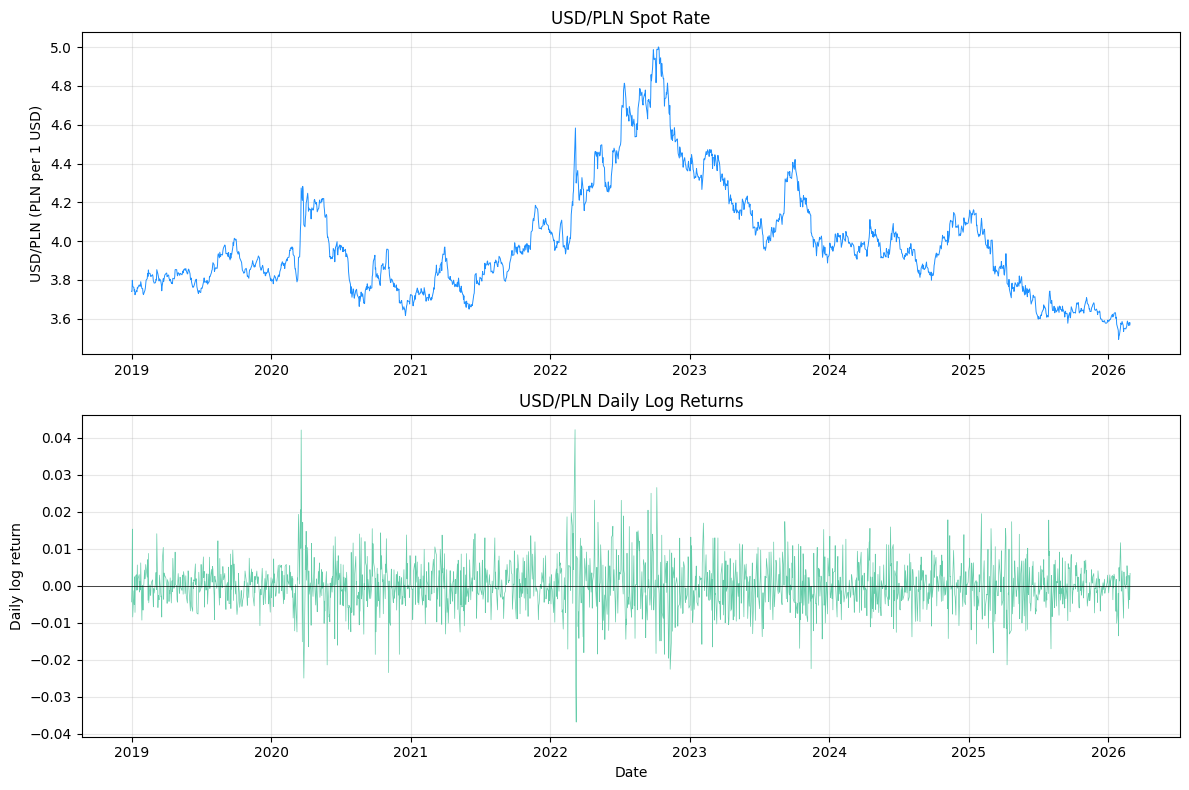

In [7]:
# visualising spot USD/PLN moves and log return moves
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# plotting spot over time
axes[0].plot(spot_data["date"], spot_data["spot_tday"], color="dodgerblue", linewidth=0.7)
axes[0].set_ylabel("USD/PLN (PLN per 1 USD)")
axes[0].set_title("USD/PLN Spot Rate")
axes[0].grid(True, alpha=0.3)

# plotting log returns over time
axes[1].plot(spot_data["date"], spot_data["log_return"], color="mediumaquamarine", linewidth=0.5)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylabel("Daily log return")
axes[1].set_xlabel("Date")
axes[1].set_title("USD/PLN Daily Log Returns")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Why B-S fails data visualisation
After applying Ito's lemma:
dlnS(t) = (r_PLN - r_USD - 0.5σ^2) dt + σdB^*(t).

We take volatility to be constant in each period, and initially completely constant across time. Therefore:

lnS(t) ~ 𝒩(lnS(t) + (r_PLN - r_USD - 0.5 σ^2)τ + στ)

lnS(t) ~ 𝒩(0, σ^2 τ)

Therefore:
Var(log_return) = σ_estimate^2 = σ^2 τ, where τ = 252 trading days in a year.


σ^2 = σ_estimate^2 /252
σ = σ_estiamte/sqrt(252)







           date  spot_tday  spot_yday  log_return  vol_annual_estimate
0    2019-01-01    3.74030    3.75685   -0.004415             0.103747
1    2019-01-02    3.74010    3.74030   -0.000053             0.103747
2    2019-01-03    3.79770    3.74010    0.015283             0.103747
3    2019-01-04    3.76560    3.79770   -0.008488             0.103747
4    2019-01-07    3.76038    3.76560   -0.001387             0.103747
...         ...        ...        ...         ...                  ...
1858 2026-02-23    3.56489    3.58708   -0.006205             0.103747
1859 2026-02-24    3.57480    3.56489    0.002776             0.103747
1860 2026-02-25    3.57904    3.57480    0.001185             0.103747
1861 2026-02-26    3.56540    3.57904   -0.003818             0.103747
1862 2026-02-27    3.57722    3.56540    0.003310             0.103747

[1863 rows x 5 columns]


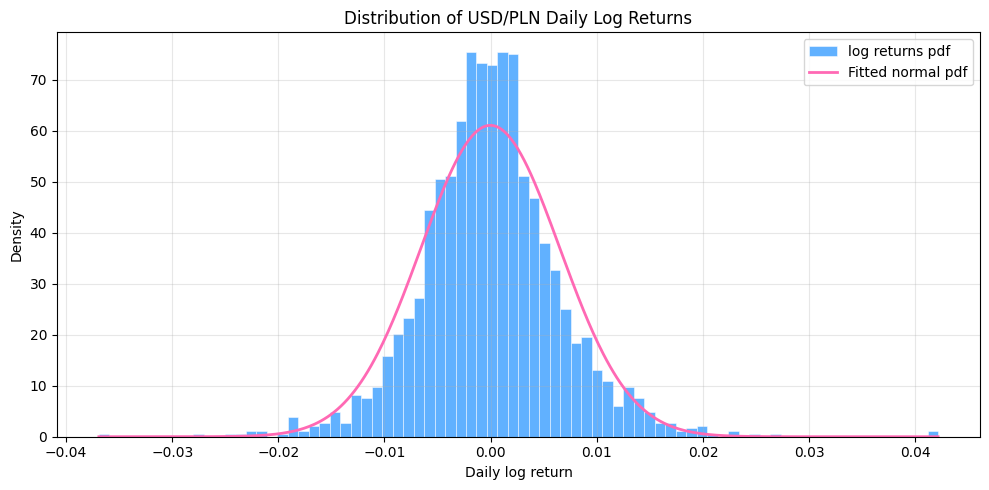

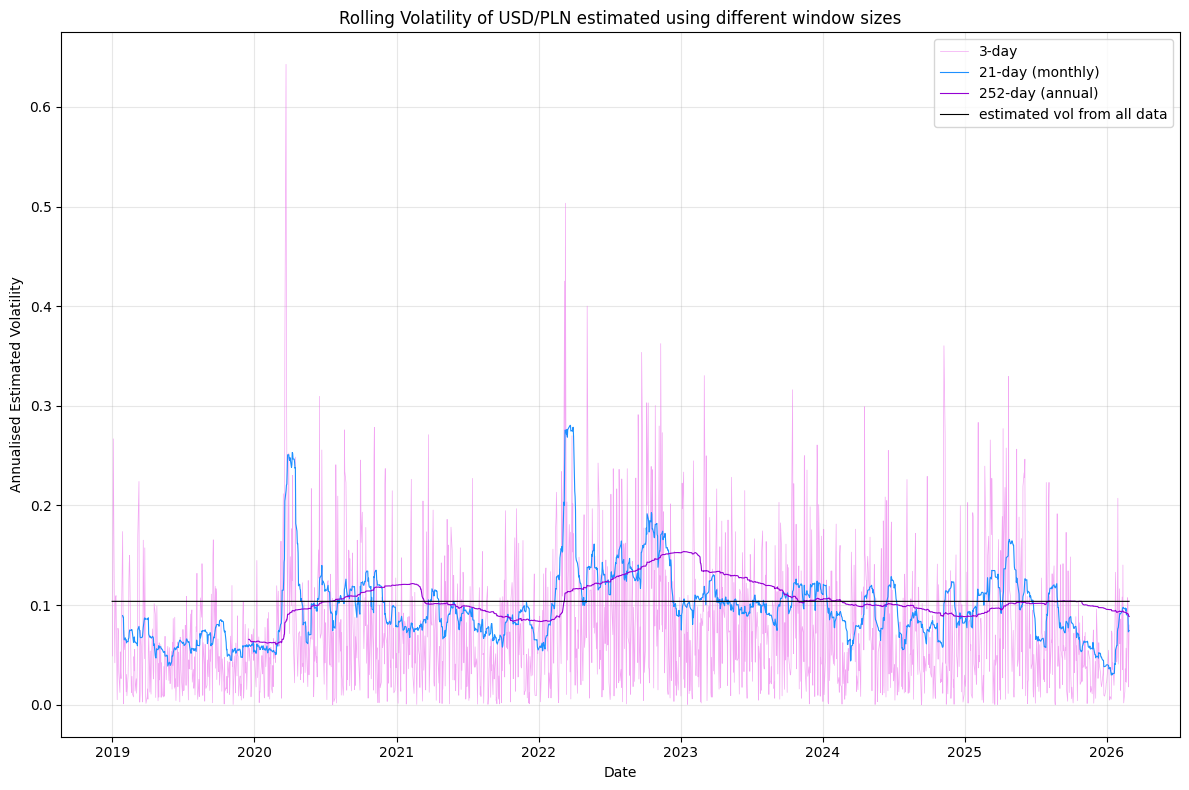

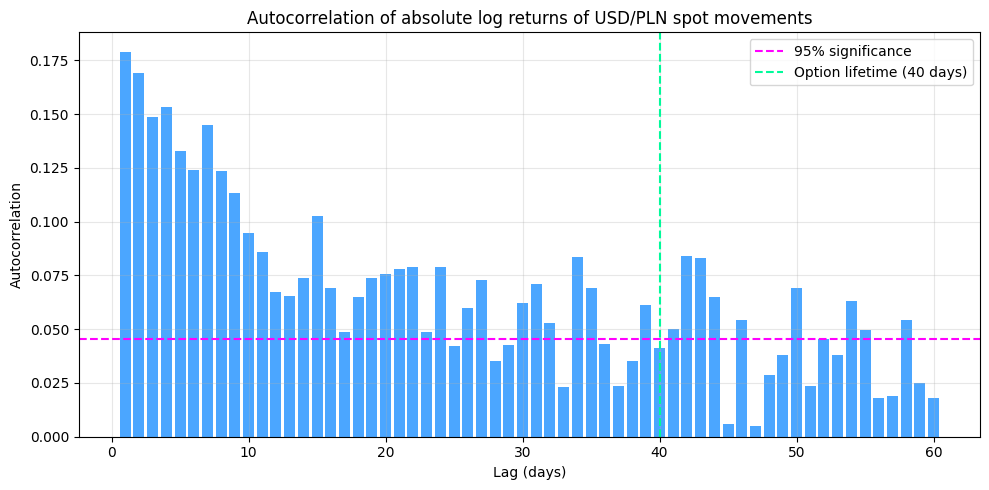

41 out of 60 lags are significant at the 5% level
mean annualised spot is  -2.6298920731420595e-05
estimated annualised vol is  [0.10374739 0.10374739 0.10374739 ... 0.10374739 0.10374739 0.10374739]
skewness of log returns is  0.23445219943587375
kurtosis of log returns is  3.170935560070836
The Jarque-Bera test p value is  SignificanceResult(statistic=np.float64(797.5738717164095), pvalue=np.float64(6.442201456408808e-174))


In [8]:
# estimating constant vol using standard deviation of log returns
sigma_daily_estimate = spot_data['log_return'].std()
sigma_annual_estimate = sigma_daily_estimate * np.sqrt(252)
spot_data['vol_annual_estimate'] = sigma_annual_estimate
print(spot_data)

# visualising distribution of log returns
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(spot_data["log_return"], bins=80, density=True, alpha=0.7,
        color="dodgerblue", edgecolor="white", linewidth=0.5, label='log returns pdf')

# overlaying with normal density with same mean and s.d as data
mu = spot_data["log_return"].mean()
sigma = spot_data["log_return"].std()
x = np.linspace(spot_data["log_return"].min(), spot_data["log_return"].max(), 500) # creates 500 evenly spaced points across data
ax.plot(x, stats.norm.pdf(x, mu, sigma), "hotpink", linewidth=2, label="Fitted normal pdf") # evaluates pdf at each linspace point

ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.set_title("Distribution of USD/PLN Daily Log Returns")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# visualising a rolling vol change
# use the past 20 days (trading month 21) for each day as a window and calculate the vol as s.d. of log returns and compare to other windows
vol_21d = spot_data["log_return"].rolling(window=20).std() * np.sqrt(252) # trading month vol
vol_3d = spot_data["log_return"].rolling(window=2).std() * np.sqrt(252) # 3 day vol
vol_252d = spot_data["log_return"].rolling(window=251).std() * np.sqrt(252) # annual vol

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(spot_data['date'], vol_3d, color="violet", linewidth=0.5, alpha=0.7, label="3-day")
ax.plot(spot_data['date'], vol_21d, color="dodgerblue", linewidth=0.8, label="21-day (monthly)")
ax.plot(spot_data['date'], vol_252d, color="darkviolet", linewidth=0.8, label="252-day (annual)")
ax.plot(spot_data['date'], spot_data['vol_annual_estimate'], color="black", linewidth=0.8, label='estimated vol from all data')

ax.set_xlabel("Date")
ax.set_ylabel("Annualised Estimated Volatility")
ax.set_title("Rolling Volatility of USD/PLN estimated using different window sizes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# plotting ACF of absolute returns to check for vol persistence
abs_acf = [spot_data["log_return"].abs().autocorr(lag=k) for k in range(1, 61)] # look at 60 day lag to see if vol correlation persists for longer than option's lifetime

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 61), abs_acf, color="dodgerblue", alpha=0.8)

# 95% significance band to check for vol clustering (ACF past confidence interval is statistically significant vol persistance)
n = len(spot_data["log_return"].dropna())
sig = 1.96 / np.sqrt(n)
ax.axhline(y=sig, color="magenta", linestyle="--", alpha=1, label="95% significance")

# option lifetime reference (40 days)
ax.axvline(x=40, color="mediumspringgreen", linestyle="--", alpha=1, label="Option lifetime (40 days)")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation of absolute log returns of USD/PLN spot movements")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# counting significant lags
sig_count = 0 # initialise count
for v in abs_acf: # looping through all lags to count ACF values that are statistically significant at 5% s.l.
    if v > sig:
        sig_count = sig_count + 1

print(f"{sig_count} out of 60 lags are significant at the 5% level")


# printing key summary statistics
print(f"mean annualised spot is ", spot_data['log_return'].mean())
print(f"estimated annualised vol is ", spot_data['vol_annual_estimate'].values)
print(f"skewness of log returns is ", stats.skew(spot_data['log_return'].values)) # measures assymetry in tails (+ means right tail longer, - means left tail longer)
print(f"kurtosis of log returns is ", stats.kurtosis(spot_data['log_return'].values)) # positive value means fatter tails than normal dist
print(f"The Jarque-Bera test p value is ", stats.jarque_bera(spot_data['log_return'].values)) # test for normal distribution, if p-value <0.05 reject normality at 5%s.l


# Varying Volatility Model
Here I adapt Paolucci (2025)'s code for generating a series of prices using a 2 latent state hidden markov model. The 2 latent states correspond to calm and stressed volatility regimes. The fitted parameters (emission means, standard deviations, and transition
matrix) are used to calibrate the regime-switching simulation environment.
In essence, a hidden markov model defines 2 states of volatility from observing data. Using the method explained by Paolucci (2025), I use a Forwards-Backwards algorithm in the Baum-Welch algorithm to calculate state and state transition probabilities. Since the main goal of this project is not modelling volatility, to conserve compute units for the delta agent training and policy exploration I use dynamic programming via the HMM to estiamte vol regimes but don't use a NN but that would be the natural extension in a more complex vol model.

References:
    Baum, L.E. et al. (1970). A Maximization Technique Occurring in the
        Statistical Analysis of Probabilistic Functions of Markov Chains.
    Paolucci (2025). [Original implementation].


Running Baum-Welch algorithm
 Iteration       Log-likelihood          Change
         0            6750.6090               —
         1            6784.6174       34.008433
         2            6792.1766        7.559153
         3            6795.8713        3.694717
         4            6798.2952        2.423918
         5            6800.2708        1.975620
         6            6802.0886        1.817829
         7            6803.8577        1.769079
         8            6805.6204        1.762725
         9            6807.3936        1.773144
        10            6809.1837        1.790154
        11            6810.9933        1.809543
        12            6812.8227        1.829397
        13            6814.6713        1.848629
        14            6816.5377        1.866371
        15            6818.4194        1.881741
        16            6820.3132        1.893749
        17            6822.2145        1.901296
        18            6824.1177        1.903201
        19

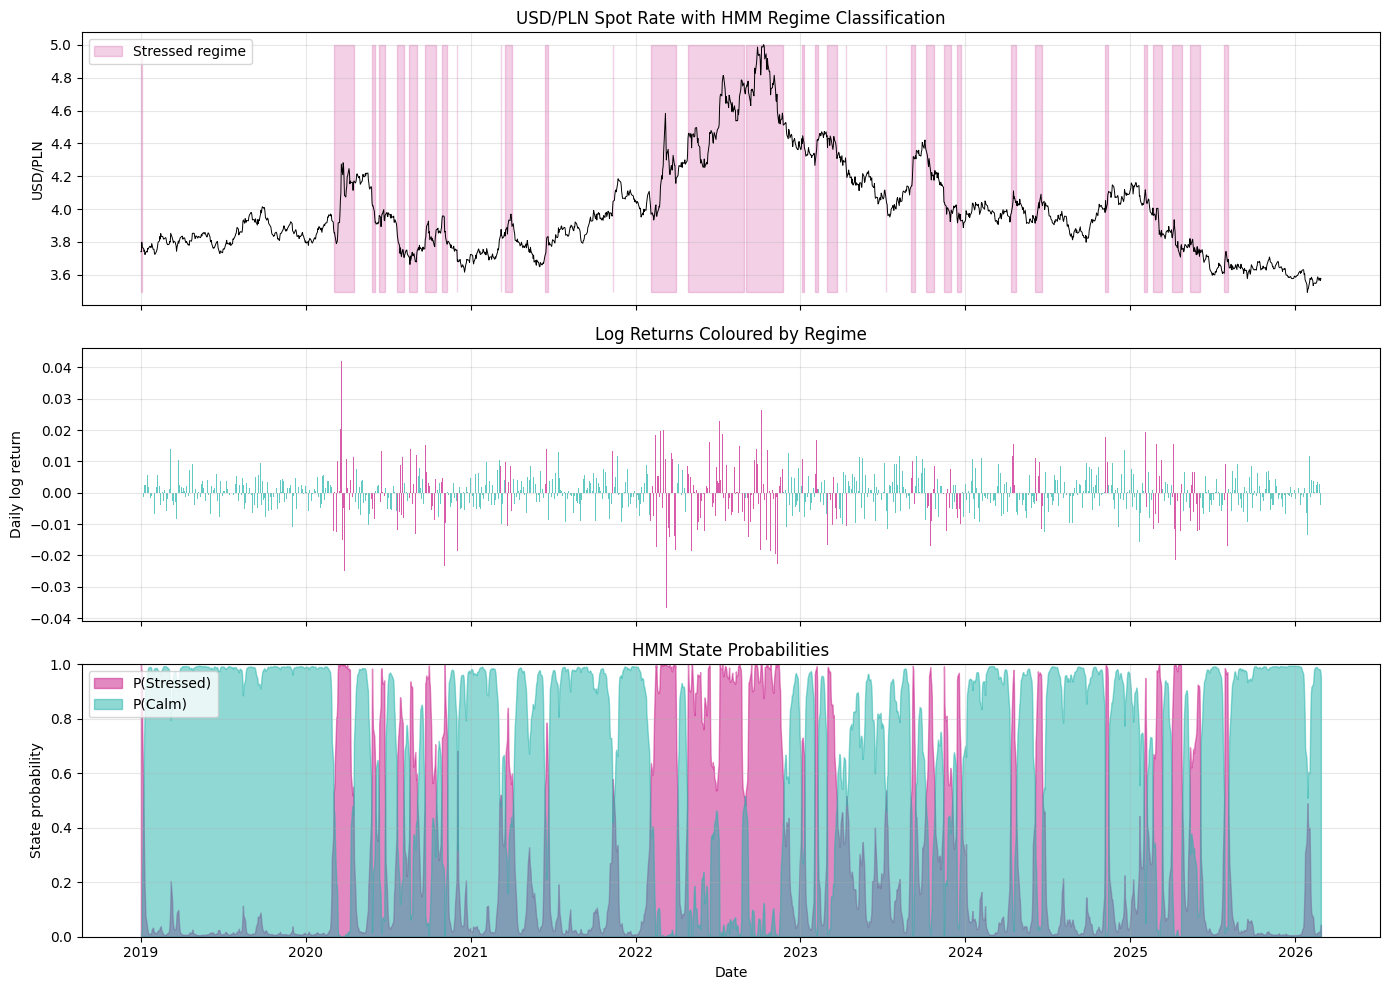

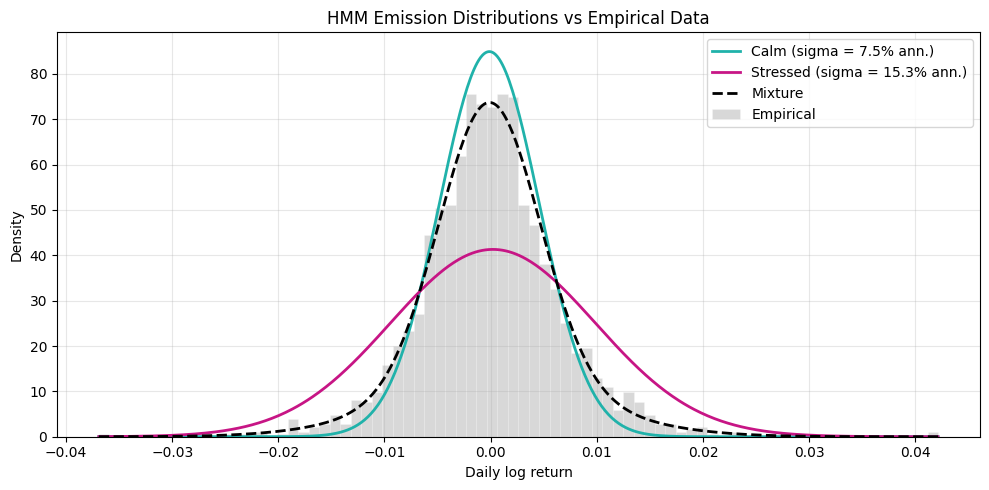

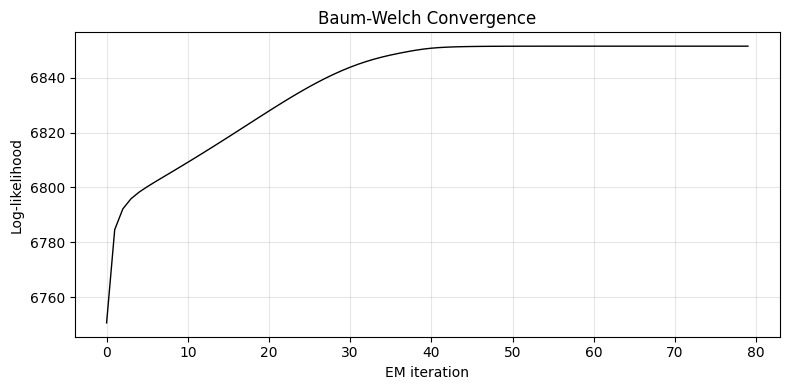

In [10]:
# organising data for HMM model
X = spot_data['log_return'].dropna().values
T = len(X)

# initialising parameters for 2-latent-state model (calm vs stressed)
N_states = 2
pi = np.ones(N_states) / N_states  # initialise state probabilities as equally likely

# transition matrix initial guess of probabilities
A = np.array([[0.5, 0.5],[0.5, 0.5],]) # initialise all transition probabilities as equally likely

# initialise observation probabilities (probabilties of getting each log return follows a gaussian dist because continuous variable)
mu = np.array([0.0, 0.0]) # intialise mean of both distributions (for both vol regimes/latent states) to 0
sigma = np.array([0.003, 0.010])  # initialise standard deviation for both distributions (guesses for calm vs stressed vol)


# forward-backwards algo from Paolucci but including scaling for numerical stability

# creating function to run forwards algo
def forward_pass(X, pi, A, mu, sigma): # takes the lambda inputs from HMM model
    T = len(X)
    N = len(pi)
    alpha = np.zeros((T, N))
    scale = np.zeros(T)

    # initialising alpha_0(j) = pi(j) * P(X_0 | state j) (but scaled for num stab)
    for j in range(N):
        alpha[0, j] = pi[j] * norm.pdf(X[0], mu[j], sigma[j])
    scale[0] = alpha[0].sum()
    if scale[0] > 0:
        alpha[0] /= scale[0]

    # inductive step (consider all possible states you could be at in time t and use alpha_t to work out chance of being in a given state using realised observations)
    for t in range(1, T):
        for j in range(N):
            # sum over all states i that could have transitioned to j (probability formula)
            alpha[t, j] = norm.pdf(X[t], mu[j], sigma[j]) * np.sum(alpha[t-1, :] * A[:, j])
        scale[t] = alpha[t].sum()
        if scale[t] > 0:
            alpha[t] = alpha[t]/scale[t]

    return alpha, scale

# creating function to run the backwards algo
def backward_pass(X, A, mu, sigma, scale): # takes lambda inputs from HMM model and a scaling factor for numerical stability
    T = len(X)
    N = A.shape[0]
    beta = np.zeros((T, N))

    # initialise: beta_T-1(i) = 1 / scale[T-1]
    beta[T-1, :] = 1.0 / scale[T-1]

    # inductive step (calc the probability of beig in a vol state given all observations (log returns) ahead)
    # beta_t(i) = sum^N_j=1 a_{ij}b_j(O_{t+1})beta_{t+1}(j)
    for t in range(T-2, -1, -1):
      for i in range(N):
          total = 0.0 # intialise summation
          for j in range(N):
              transition_prob = A[i, j] # a_{ij}
              emission_prob = norm.pdf(X[t+1], mu[j], sigma[j]) # b_j(O_{t_1})
              future_prob = beta[t+1, j] # beta{t+1}(j)
              total += transition_prob * emission_prob * future_prob
          beta[t, i] = total
    # scale after iterating and calculating summation
      beta[t, :] /= scale[t]
    return beta


# Baum-Welch algorithm
max_iter = 200  # setting a cap on iterations before convergence
tol = 1e-6 # defining what's 'near enough' zero so algo doesn't take too long to run
log_likelihoods = []

#printing updates for iterations to track progress
print("\nRunning Baum-Welch algorithm")
print(f"{'Iteration':>10} {'Log-likelihood':>20} {'Change':>15}")

for iteration in range(max_iter):
    # E-step (expectation by running fwd-bckwd algo)
    alpha, scale = forward_pass(X, pi, A, mu, sigma)
    beta = backward_pass(X, A, mu, sigma, scale)

    # calculating gamma from alpha and beta: P(q_i = S_i | observations, lambda)
    gamma = alpha * beta
    gamma_sum = gamma.sum(axis=1, keepdims=True) # sum across columns keeping result as column vector
    gamma_sum[gamma_sum == 0] = 1e-300  # preventing zero div
    gamma = gamma / gamma_sum # using Bayes' rule

    # Xi = P(q_t = S_i, q_{t+1} = S_j | observations, lambda) i.e probability of a transition occuring
    # Xi = frac{alpha_t(i)*a_{ij}*b_j(O_{t=1})*beta_{t+1}(j)}/{sum of numerator over i and over j}
    xi = np.zeros((T-1, N_states, N_states))
    for t in range(T-1):
        for i in range(N_states):
            for j in range(N_states):
                xi[t, i, j] = (alpha[t, i] * A[i, j] * norm.pdf(X[t+1], mu[j], sigma[j]) * beta[t+1, j])
        xi_sum = xi[t].sum()
        if xi_sum > 0:
            xi[t] /= xi_sum

    # M-step (maximisation)
    # update initial state probabilities
    pi = gamma[0]

    # update transition matrix
    # A_{ij} = expected number of transitions from i to j (sum of Xi) / expected number of times model was in state i (sum of gamma(i))
    for i in range(N_states):
        denom = gamma[:-1, i].sum()
        if denom > 0:
            for j in range(N_states):
                A[i, j] = xi[:, i, j].sum() / denom

    # update observation gaussian parameters (mean and std for each state)
    # gamma tells you how likely it is that a given log return move contributes to the dists of calm vs stressed
    for j in range(N_states):
        weight = gamma[:, j]
        weight_sum = weight.sum()
        if weight_sum > 0:
            mu[j] = np.sum(weight * X) / weight_sum
            sigma[j] = np.sqrt(np.sum(weight * (X - mu[j])**2) / weight_sum)
            # Floor sigma to avoid degenerate states
            sigma[j] = max(sigma[j], 1e-6)

    # check for convergence and stop iterating once converged
    log_likelihood = np.sum(np.log(np.maximum(scale, 1e-300)))
    log_likelihoods.append(log_likelihood)

    if iteration > 0:
        change = log_likelihood - log_likelihoods[-2]
        print(f"{iteration:>10} {log_likelihood:>20.4f} {change:>15.6f}")
        if abs(change) < tol:
            print(f"\nConverged after {iteration + 1} iterations.")
            break
    else:
        print(f"{iteration:>10} {log_likelihood:>20.4f} {'—':>15}")

if iteration == max_iter - 1:
    print(f"\nReached maximum iterations ({max_iter}).")

# pulling parameters from model
# sort states as lowest sigma = calm vol, highest sigma = stressed vol
state_order = np.argsort(sigma)  # index of sigmas in ascending order
calm_idx = state_order[0] # lowest sigma always calm
stressed_idx = state_order[1] # highest sigma always stressed

# most likely state at each time step (is the day calm or stressed vol)
hidden_states = np.argmax(gamma, axis=1)
stressed = (hidden_states == stressed_idx) # labelling the days
regimes = np.where(stressed, "Stressed", "Calm")
sigma_calm = sigma[calm_idx]
sigma_stressed = sigma[stressed_idx]
mu_calm = mu[calm_idx]
mu_stressed = mu[stressed_idx]

# add hidden states and gamma values to spot data df
spot_data['HMM_state'] = hidden_states # 0 for calm 1 for stressed for every day
spot_data['p_calm_tday'] = gamma[:, calm_idx] # what's chance of calm regime each day
spot_data['p_stressed_tday'] = gamma[:, stressed_idx] # what's chance of stressed regime each day


# pulling transition probabilities
p_calm_to_stressed = A[calm_idx, stressed_idx]
p_stressed_to_calm = A[stressed_idx, calm_idx]
# calculating time spent in calm vs stressed from geometric distribution
# bc we assume probabilities of staying or leaving vol regime are iid
# therefore if chance p of staying in regime, E[days in regime] = 1/p
avg_calm_duration = 1.0 / p_calm_to_stressed if p_calm_to_stressed > 0 else np.inf
avg_stressed_duration = 1.0 / p_stressed_to_calm if p_stressed_to_calm > 0 else np.inf
frac_calm = (regimes == "Calm").mean()
frac_stressed = (regimes == "Stressed").mean()


calibrated_params = {
    "Daily mean": {"Calm": mu_calm, "Stressed": mu_stressed},
    "Daily std": {"Calm": sigma_calm, "Stressed": sigma_stressed},
    "Estimated Annualised vol": {"Calm": sigma_calm * np.sqrt(252), "Stressed": sigma_stressed * np.sqrt(252)},
    "P(stay in regime)": {"Calm": A[calm_idx, calm_idx], "Stressed": A[stressed_idx, stressed_idx]},
    "P(switch)": {"Calm": p_calm_to_stressed, "Stressed": p_stressed_to_calm},
    "Avg duration of vol regime (days)": {"Calm": avg_calm_duration, "Stressed": avg_stressed_duration},
    "Portion of time spent in each regime": {"Calm": frac_calm * 100, "Stressed": frac_stressed * 100}}

transition_matrix = {"From Calm": {"To Calm": A[calm_idx, calm_idx], "To Stressed": A[calm_idx, stressed_idx]},
                     "From Stressed": {"To Calm": A[stressed_idx, calm_idx], "To Stressed": A[stressed_idx, stressed_idx]}}

vol_summary_df = pd.DataFrame(calibrated_params)
print(vol_summary_df)
transition_df = pd.DataFrame(transition_matrix)
print(transition_df)

# visualising results
# plotting regime over time
dates = spot_data['date'].values
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# panel 1 spot price with regime shading
axes[0].plot(dates, spot_data['spot_tday'].values, color='black', linewidth=0.7)
axes[0].fill_between(dates, spot_data['spot_tday'].min(), spot_data['spot_tday'].max(),
                     where=stressed, alpha=0.2, color='mediumvioletred', label='Stressed regime')
axes[0].set_ylabel("USD/PLN")
axes[0].set_title("USD/PLN Spot Rate with HMM Regime Classification")
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# panle 2 log returns with regime shading
regime_log_r = spot_data.dropna(subset=['log_return']).copy()
axes[1].bar(regime_log_r['date'],regime_log_r['log_return'],
            color=np.where(stressed, 'mediumvioletred', 'lightseagreen'), alpha=0.7, width=1)
axes[1].set_ylabel("Daily log return")
axes[1].set_title("Log Returns Coloured by Regime")
axes[1].grid(True, alpha=0.3)

# panel 3 state probabilities
axes[2].fill_between(dates, 0, gamma[:, stressed_idx], alpha=0.5, color='mediumvioletred',
                     label='P(Stressed)')
axes[2].fill_between(dates, 0, gamma[:, calm_idx], alpha=0.5, color='lightseagreen',
                     label='P(Calm)')
axes[2].set_ylabel("State probability")
axes[2].set_xlabel("Date")
axes[2].set_title("HMM State Probabilities")
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()



# plotting mean and s.d. for each vol state
fig, ax = plt.subplots(figsize=(10, 5))
x_grid = np.linspace(X.min(), X.max(), 500)

# calm state distribution
pdf_calm = norm.pdf(x_grid, mu_calm, sigma_calm)
ax.plot(x_grid, pdf_calm, color='lightseagreen', linewidth=2,
        label=f'Calm (sigma = {sigma_calm*np.sqrt(252):.1%} ann.)')

# stressed state distribution
pdf_stressed = norm.pdf(x_grid, mu_stressed, sigma_stressed)
ax.plot(x_grid, pdf_stressed, color='mediumvioletred', linewidth=2,
        label=f'Stressed (sigma = {sigma_stressed*np.sqrt(252):.1%} ann.)')

# weighted sum of calm and stressed gaussian pdf to give HMM mixed distribution
pdf_mixture = frac_calm * pdf_calm + frac_stressed * pdf_stressed
ax.plot(x_grid, pdf_mixture, color='black', linewidth=2, linestyle='--',
        label='Mixture')

# empirical histogram for comparison
ax.hist(X, bins=80, density=True, alpha=0.3, color='grey', edgecolor='white',
        linewidth=0.5, label='Empirical')

ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.set_title("HMM Emission Distributions vs Empirical Data")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# plotting EM convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(log_likelihoods)), log_likelihoods, color='black', linewidth=1)
ax.set_xlabel("EM iteration")
ax.set_ylabel("Log-likelihood")
ax.set_title("Baum-Welch Convergence")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Simulating spot prices using calibrated parameters (go over HMM sim code)

*   simulate with GBM constant vol
*   simulate with regime switching HMM calibrated parameter vol

*   compare simulations to actual data

Everything is calculated from the base equation:
S(T) = S(t) exp[(mu - 1/2σ^2)Δt + σsqrt(Δt)Z], where Z is the standard normal distribution



      sim_prices
0       3.740300
1       3.738852
2       3.735958
3       3.761302
4       3.730358
...          ...
1858    2.591569
1859    2.589795
1860    2.581389
1861    2.573979
1862    2.552067

[1863 rows x 1 columns]


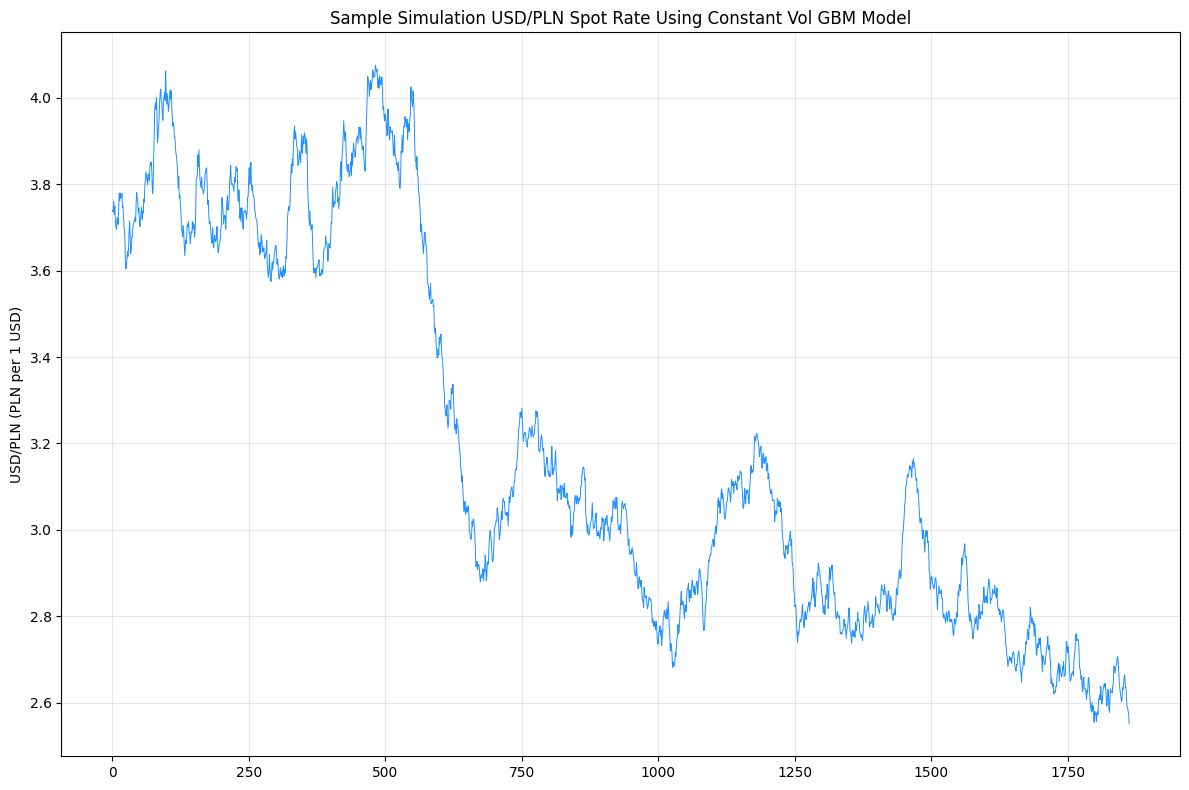

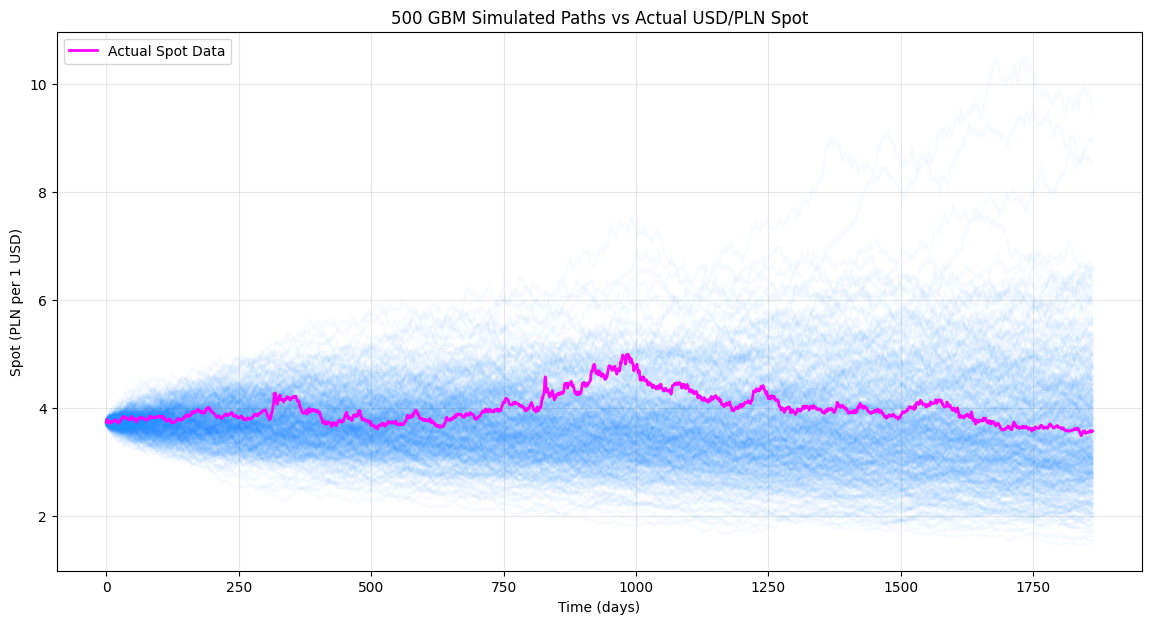

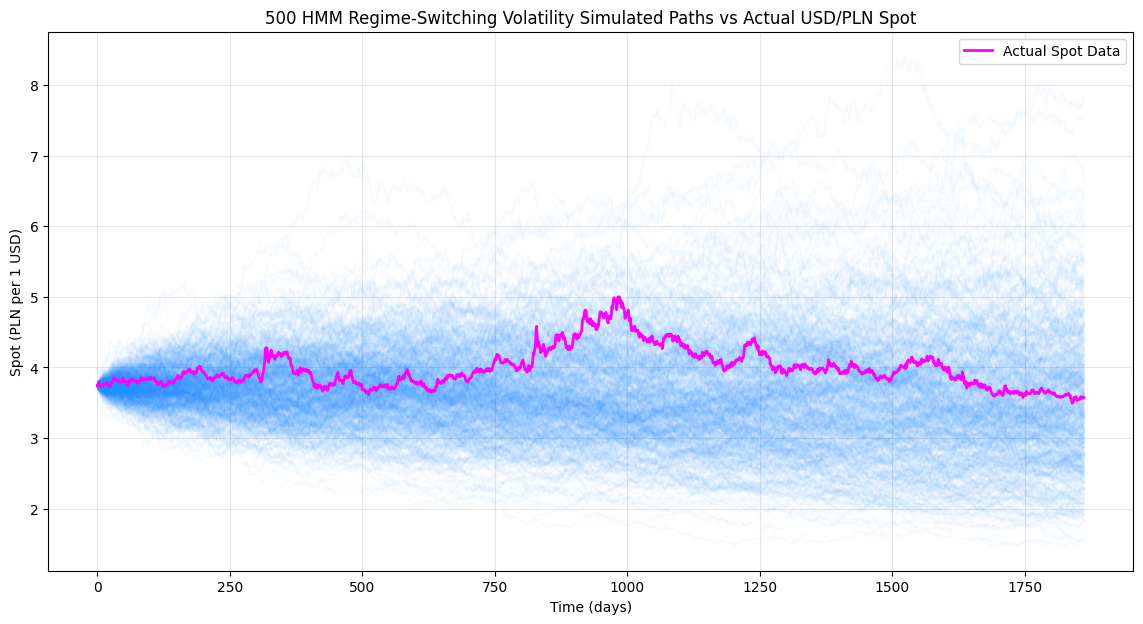

In [15]:
# initial parameters
np.random.seed(21)
T = len(spot_data)
dt = 1/252 # one day in the trading year
S_0 = spot_data['spot_tday'].iloc[0] # starting price

# historical drift (mean) and vol (s.d.) for GBM
sample_mu = spot_data['log_return'].mean()
sample_sigma = spot_data['log_return'].std()
sample_mu_annual = sample_mu * 252 # working from annual lens of Ito lemma derivation
sample_sigma_annual = sample_sigma * np.sqrt(252)


# simulating one episode of prices using GBM empirical constant vol model
x = np.linspace(0, T, T)
s = np.zeros(T)
s[0] = S_0
for t in range(1, T):
  s[t] = s[t-1] * np.exp((sample_mu_annual - (0.5 * sample_sigma_annual**2)) * dt
                         + sample_sigma_annual * np.sqrt(dt) * np.random.normal(0,1))

# storing generated spot prices in df to plot
GBM_s_sim_1 = pd.DataFrame()
GBM_s_sim_1['sim_prices'] = s
print(GBM_s_sim_1)

# plotting 1 simulation from GBM for intuition
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(GBM_s_sim_1['sim_prices'], color="dodgerblue", linewidth=0.7)
ax.set_ylabel("USD/PLN (PLN per 1 USD)")
ax.set_title("Sample Simulation USD/PLN Spot Rate Using Constant Vol GBM Model")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# generating many simulations (vector of 500 paths)
n_paths = 500
# create 500 * 1862 (n_paths x T) vector with values
eps = np.random.normal(0,1, size=(n_paths, T))
# scalar multiplication of the spot price generation formula to random number matrix
sim_log_returns = ((sample_mu_annual - (0.5 * sample_sigma_annual**2)) * dt
+ sample_sigma_annual * np.sqrt(dt) * eps)
# sum values in each column to get evolution of spot over time for each episode
cum_sim_log_returns = np.cumsum(sim_log_returns, axis = 1) # to get price for t+1, t+2 + ... + T

# convert to price paths
gbm_paths = S_0 * np.exp(cum_sim_log_returns)

# plotting fan of simmed paths with actual data as comparison
plt.figure(figsize=(14, 7))
# plot GBM paths
for i in range(n_paths):
    plt.plot(gbm_paths[i], color='dodgerblue', alpha=0.03) # plotting sims
plt.plot(spot_data['spot_tday'].values, color='magenta', linewidth=2, label='Actual Spot Data')
plt.title("500 GBM Simulated Paths vs Actual USD/PLN Spot")
plt.xlabel("Time (days)")
plt.ylabel("Spot (PLN per 1 USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# calibrated parameters from HMM model (referencing data from previous block of code)
HMM_sigma_calm = sigma_calm
HMM_sigma_stressed = sigma_stressed
HMM_mu_calm = mu_calm
HMM_mu_stressed = mu_stressed

# annualising parameters
HMM_s_c_a = HMM_sigma_calm * np.sqrt(252)
HMM_s_s_a = HMM_sigma_stressed * np.sqrt(252)
HMM_m_c_a = HMM_mu_calm * 252
HMM_m_s_a = HMM_mu_stressed * 252

# transition probabilities
HMM_p_cs = p_calm_to_stressed
HMM_p_sc = p_stressed_to_calm

# creating matrix to store prices
HMM_paths_shape = (n_paths, T)
HMM_paths = np.zeros(HMM_paths_shape)
HMM_paths[:, 0] = S_0 # every episode starts with today's spot

# simulating the HMM paths:
for i in range(n_paths):
  in_stressed = False  # start with calm regime to match data
  for t in range (1,T): # looping through all the 1862 days
    if in_stressed:
      mu_t = HMM_m_s_a
      sig_t = HMM_s_s_a
    else: # for calm regime
      mu_t = HMM_m_c_a
      sig_t = HMM_s_c_a
    # ito derivation of spot evolution
    HMM_paths[i, t] = (HMM_paths[i, t-1] * np.exp((mu_t - 0.5 * sig_t**2) * dt
    + sig_t * np.sqrt(dt) * np.random.normal(0,1)))

    # applying transition probabilities
    if in_stressed:  # when in stressed
      if np.random.rand() < HMM_p_sc:  # draw random number from uniform [0,1]
        in_stressed = False  # if number < switch transition then swap regime
    else:  # when in calm
      if np.random.rand() < HMM_p_cs:
          in_stressed = True

# plotting HMM simulations
plt.figure(figsize = (14, 7))
for i in range (n_paths):
  plt.plot(HMM_paths[i], color='dodgerblue', alpha = 0.03) # plotting sims
plt.plot(spot_data['spot_tday'].values, color='magenta', linewidth=2,
label='Actual Spot Data')
plt.title('500 HMM Regime-Switching Volatility Simulated Paths vs Actual USD/PLN Spot')
plt.xlabel('Time (days)')
plt.ylabel('Spot (PLN per 1 USD)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Downloading Data for next notebook (environment design, prediction and control)

Only run the cell below if you want to download csv's of statistics pulled in this notebook to your local device (a copy of the csv's will be in my submission file either way)

In [17]:
from google.colab import files
spot_data.to_csv('USDPLN_spot_data.csv')
vol_summary_df.to_csv('HMM_calibrated_params.csv')
transition_df.to_csv('HMM_transition_matrix.csv')
files.download('USDPLN_spot_data.csv')
files.download('HMM_calibrated_params.csv')
files.download('HMM_transition_matrix.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>